#Detecção de pontos corporais

In [32]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


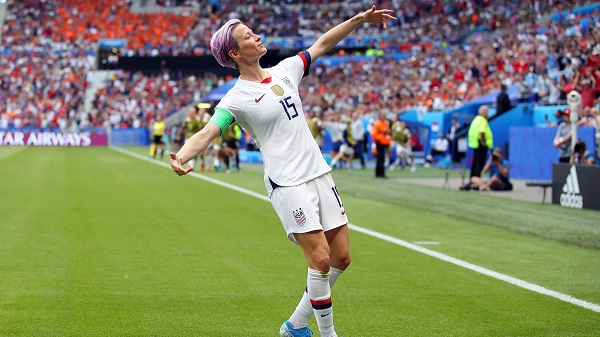

In [34]:
imagem = cv2.imread('/content/drive/MyDrive/Colab Notebooks/Images/megan.jpg')
cv2_imshow(imagem)

In [35]:
imagem.shape

(337, 600, 3)

In [ ]:
type(imagem)

In [36]:
# Mean subtraction: https://www.pyimagesearch.com/2017/11/06/deep-learning-opencvs-blobfromimage-works/
imagem_blob = cv2.dnn.blobFromImage(image = imagem, scalefactor = 1.0/255,
                                    size = (imagem.shape[1], imagem.shape[0]))

In [37]:
imagem_blob.shape # batch

(1, 3, 337, 600)

In [38]:
type(imagem_blob)

numpy.ndarray

#Carregamento de rede neural pré-treinada

In [39]:
network = cv2.dnn.readNetFromCaffe('/content/drive/MyDrive/Colab Notebooks/Weights/pose_deploy_linevec_faster_4_stages.prototxt',
                                   '/content/drive/MyDrive/Colab Notebooks/Weights/pose_iter_160000.caffemodel')

In [40]:
network.getLayerNames()

('conv1_1',
 'relu1_1',
 'conv1_2',
 'relu1_2',
 'pool1_stage1',
 'conv2_1',
 'relu2_1',
 'conv2_2',
 'relu2_2',
 'pool2_stage1',
 'conv3_1',
 'relu3_1',
 'conv3_2',
 'relu3_2',
 'conv3_3',
 'relu3_3',
 'conv3_4',
 'relu3_4',
 'pool3_stage1',
 'conv4_1',
 'relu4_1',
 'conv4_2',
 'relu4_2',
 'conv4_3_CPM',
 'relu4_3_CPM',
 'conv4_4_CPM',
 'relu4_4_CPM',
 'conv5_1_CPM_L1',
 'relu5_1_CPM_L1',
 'conv5_1_CPM_L2',
 'relu5_1_CPM_L2',
 'conv5_2_CPM_L1',
 'relu5_2_CPM_L1',
 'conv5_2_CPM_L2',
 'relu5_2_CPM_L2',
 'conv5_3_CPM_L1',
 'relu5_3_CPM_L1',
 'conv5_3_CPM_L2',
 'relu5_3_CPM_L2',
 'conv5_4_CPM_L1',
 'relu5_4_CPM_L1',
 'conv5_4_CPM_L2',
 'relu5_4_CPM_L2',
 'conv5_5_CPM_L1',
 'conv5_5_CPM_L2',
 'concat_stage2',
 'Mconv1_stage2_L1',
 'Mrelu1_stage2_L1',
 'Mconv1_stage2_L2',
 'Mrelu1_stage2_L2',
 'Mconv2_stage2_L1',
 'Mrelu2_stage2_L1',
 'Mconv2_stage2_L2',
 'Mrelu2_stage2_L2',
 'Mconv3_stage2_L1',
 'Mrelu3_stage2_L1',
 'Mconv3_stage2_L2',
 'Mrelu3_stage2_L2',
 'Mconv4_stage2_L1',
 'Mrelu4_sta

#Previsão dos pontos corporais

In [41]:
network.setInput(imagem_blob)
output=network.forward()

In [42]:
output.shape

(1, 44, 43, 75)

In [43]:
posicao_largura = output.shape[3]
posicao_altura = output.shape[2]

In [44]:
posicao_altura, posicao_largura

(43, 75)

In [45]:
numero_pontos = 15
pontos = []
threshold = 0.1
for i in range(numero_pontos):
  mapa_confianca = output[0, i, :, :]
  _, confianca, _, ponto = cv2.minMaxLoc(mapa_confianca)
  x = int(ponto[0] * (imagem.shape[1] / posicao_largura))
  y = int(ponto[1] * (imagem.shape[0] / posicao_altura))
  if confianca > threshold:
    cv2.circle(imagem, (x, y), 5, (0,255,0), thickness = -1)
    cv2.putText(imagem, '{}'.format(i), (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255))
    pontos.append((x,y))
  else:
    pontos.append(None)

In [46]:
pontos

[(224, 23),
 (248, 62),
 (232, 94),
 (208, 125),
 (176, 148),
 (280, 62),
 (320, 39),
 (360, 15),
 (288, 180),
 (320, 250),
 (320, 321),
 (312, 164),
 (336, 250),
 (296, 305),
 (280, 125)]

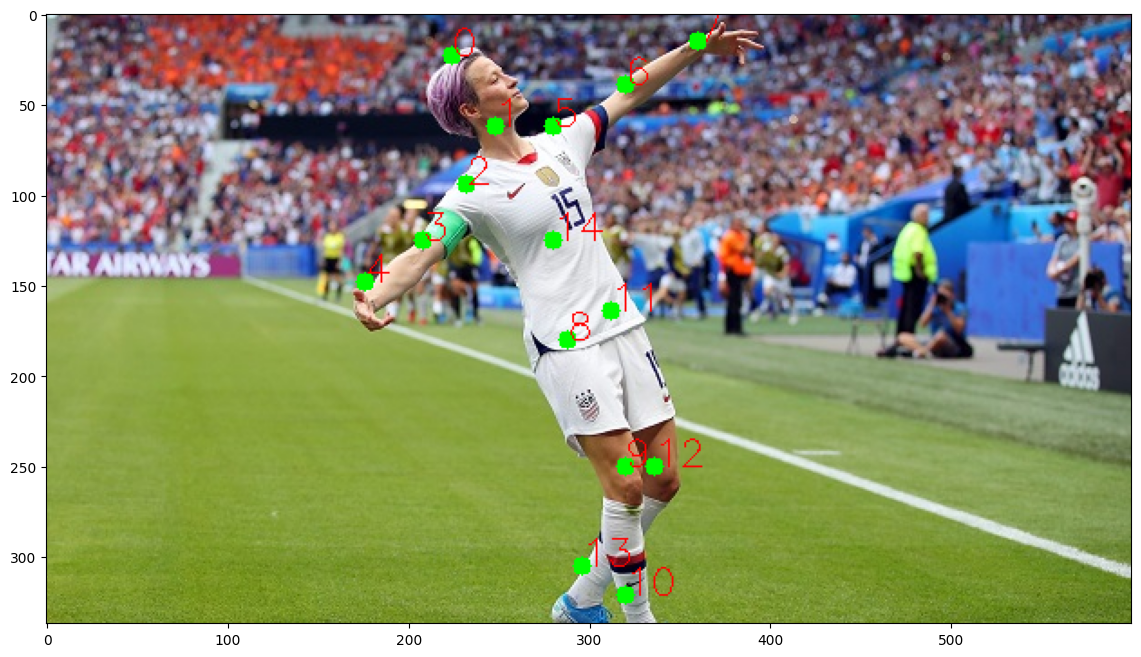

In [47]:
plt.figure(figsize=(14,10))
plt.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB));


In [48]:
ponto_conexoes = [[0,1], [1,2], [2,3], [3,4], [1,5], [5,6], [6,7], [1, 14],
                  [14,8], [8,9], [9,10], [14,11], [11,12],[12,13]]

In [49]:
pontos

[(224, 23),
 (248, 62),
 (232, 94),
 (208, 125),
 (176, 148),
 (280, 62),
 (320, 39),
 (360, 15),
 (288, 180),
 (320, 250),
 (320, 321),
 (312, 164),
 (336, 250),
 (296, 305),
 (280, 125)]

In [52]:
for conexoes in ponto_conexoes:
  #print(conexoes)
  partea = conexoes[0]
  parteb = conexoes[1]

  if pontos[partea] and pontos[parteb]:
    cv2.line(imagem, pontos[partea], pontos[parteb], (255,0,0))

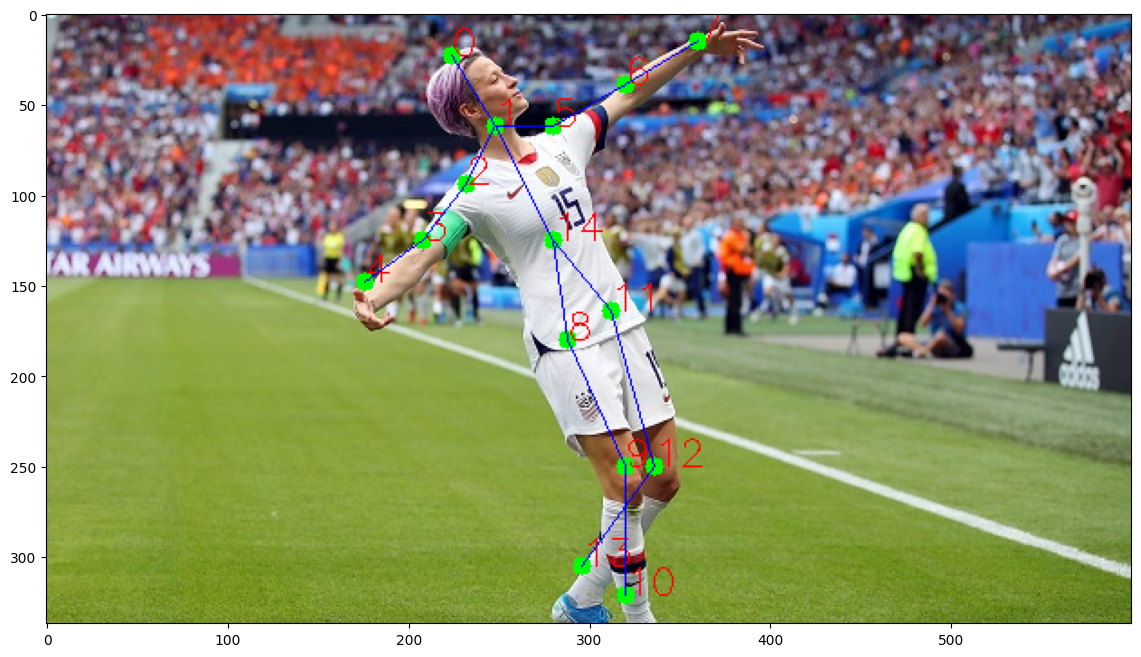

In [51]:
plt.figure(figsize=(14,10))
plt.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB));

## Braços acima da cabeça em imagens

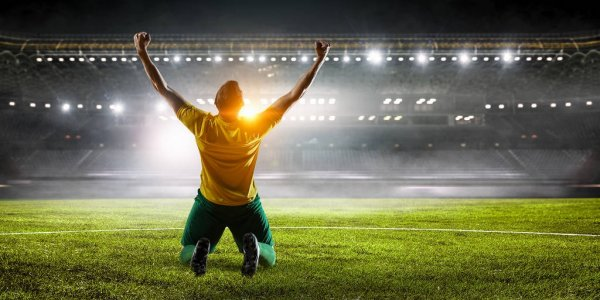

In [53]:
imagem2 = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Images/player.jpg")
cv2_imshow(imagem2)

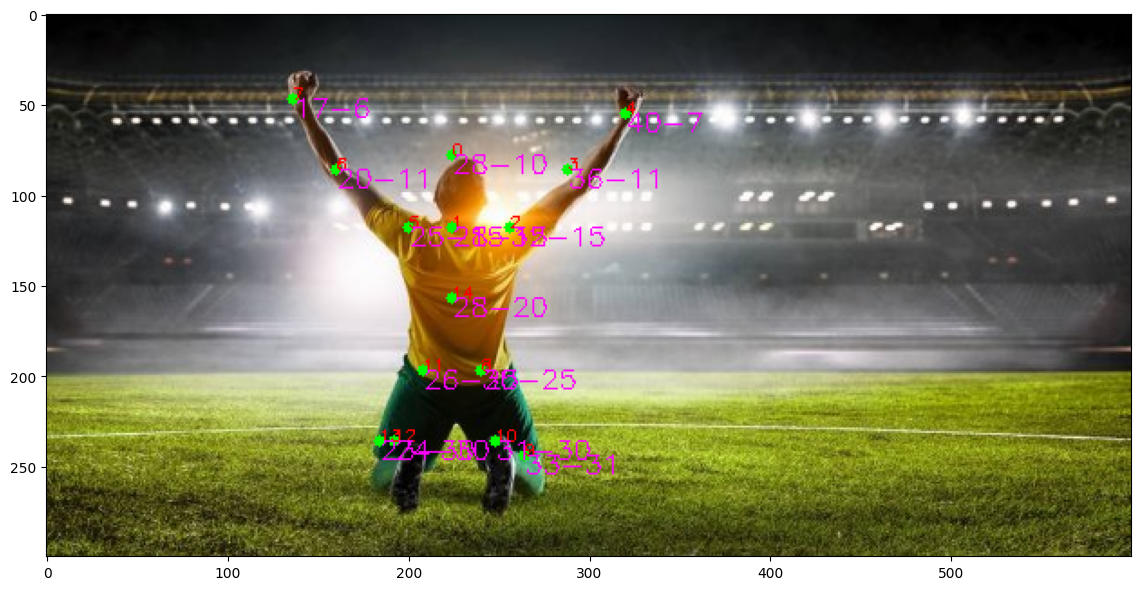

In [54]:
imagem2 = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Images/player.jpg")
imagem_blob2 = cv2.dnn.blobFromImage(image = imagem2, scalefactor = 1.0 / 255, size = (imagem2.shape[1], imagem2.shape[0]))
network.setInput(imagem_blob2)
output2 = network.forward()
posicao_largura = output2.shape[3]
posicao_altura = output2.shape[2]
numero_pontos = 15
pontos = []
threshold = 0.1
for i in range(numero_pontos):
  mapa_confianca = output2[0, i, :, :]
  _, confianca, _, ponto = cv2.minMaxLoc(mapa_confianca)
  x = int((imagem2.shape[1] * ponto[0]) / posicao_largura)
  y = int((imagem2.shape[0] * ponto[1]) / posicao_altura)

  if confianca > threshold:
    cv2.circle(imagem2, (x, y), 3, (0,255,0), thickness = -1)
    cv2.putText(imagem2, "{}".format(i), (x, y), cv2.FONT_HERSHEY_SIMPLEX, .3, (0, 0, 255))
    cv2.putText(imagem2, '{}-{}'.format(ponto[0], ponto[1]), (x, y + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,255))
    pontos.append((x, y))
  else:
    pontos.append(None)

plt.figure(figsize = [14,10])
plt.imshow(cv2.cvtColor(imagem2, cv2.COLOR_BGR2RGB));

In [55]:
def verifica_bracos_acima(pontos):
  cabeca, pulso_direito, pulso_esquerdo = 0, 0, 0
  for i, ponto in enumerate(pontos):
    #print(i, ponto)
    if i == 0:
      cabeca = ponto[1]
    elif i == 4:
      pulso_direito = ponto[1]
    elif i == 7:
      pulso_esquerdo = ponto[1]

  if pulso_direito < cabeca and pulso_esquerdo < cabeca:
    return True
  else:
    return False

In [56]:
verifica_bracos_acima(pontos)

True

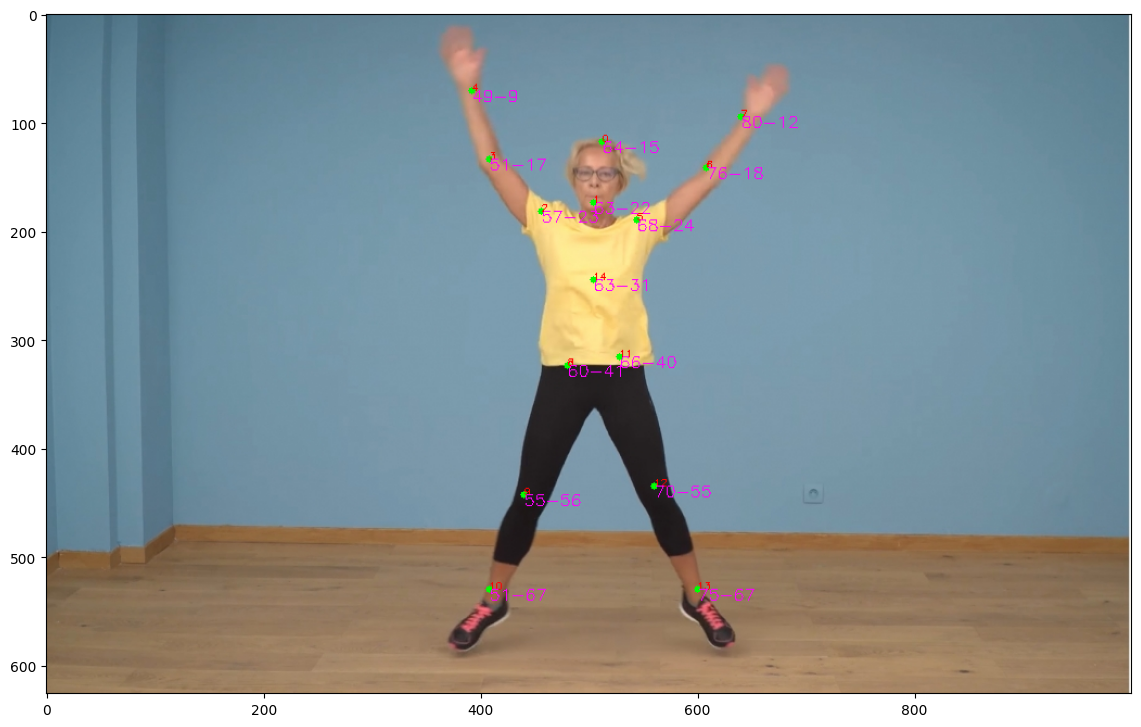

In [57]:
imagem2 = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Images/jump.jpg")
imagem_blob2 = cv2.dnn.blobFromImage(image = imagem2, scalefactor = 1.0 / 255, size = (imagem2.shape[1], imagem2.shape[0]))
network.setInput(imagem_blob2)
output2 = network.forward()
posicao_largura = output2.shape[3]
posicao_altura = output2.shape[2]
numero_pontos = 15
pontos = []
threshold = 0.1
for i in range(numero_pontos):
  mapa_confianca = output2[0, i, :, :]
  _, confianca, _, ponto = cv2.minMaxLoc(mapa_confianca)
  x = int((imagem2.shape[1] * ponto[0]) / posicao_largura)
  y = int((imagem2.shape[0] * ponto[1]) / posicao_altura)

  if confianca > threshold:
    cv2.circle(imagem2, (x, y), 3, (0,255,0), thickness = -1)
    cv2.putText(imagem2, "{}".format(i), (x, y), cv2.FONT_HERSHEY_SIMPLEX, .3, (0, 0, 255))
    cv2.putText(imagem2, '{}-{}'.format(ponto[0], ponto[1]), (x, y + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,255))
    pontos.append((x, y))
  else:
    pontos.append(None)

plt.figure(figsize = [14,10])
plt.imshow(cv2.cvtColor(imagem2, cv2.COLOR_BGR2RGB));

In [58]:
def verifica_pernas_afastadas(pontos):
  quadril_esquerdo, quadril_direito = 0, 0
  tornozelo_esquerdo, tornozelo_direito = 0, 0

  for i, ponto in enumerate(pontos):
    if i == 11:
      quadril_esquerdo = ponto[0]
    elif i == 8:
      quadril_direito = ponto[0]
    elif i == 13:
      tornozelo_esquerdo = ponto[0]
    elif i == 10:
      tornozelo_direito = ponto[0]

  if (tornozelo_esquerdo > quadril_esquerdo) and (tornozelo_direito < quadril_direito):
    return True
  else:
    return False

In [59]:
verifica_pernas_afastadas(pontos)

True

#Braços acima da cabeça em vídeos

In [60]:
video = "/content/drive/MyDrive/Colab Notebooks/Videos/gesture1.mp4"
captura = cv2.VideoCapture(video)
conectado, frame = captura.read()
print(conectado, frame.shape)

True (1080, 808, 3)


In [61]:
resultado = "/content/drive/MyDrive/Colab Notebooks/Videos/gesture1.mp4"
salva_video = cv2.VideoWriter(resultado, cv2.VideoWriter_fourcc(*'MP4V'), 10, (frame.shape[1], frame.shape[0]))

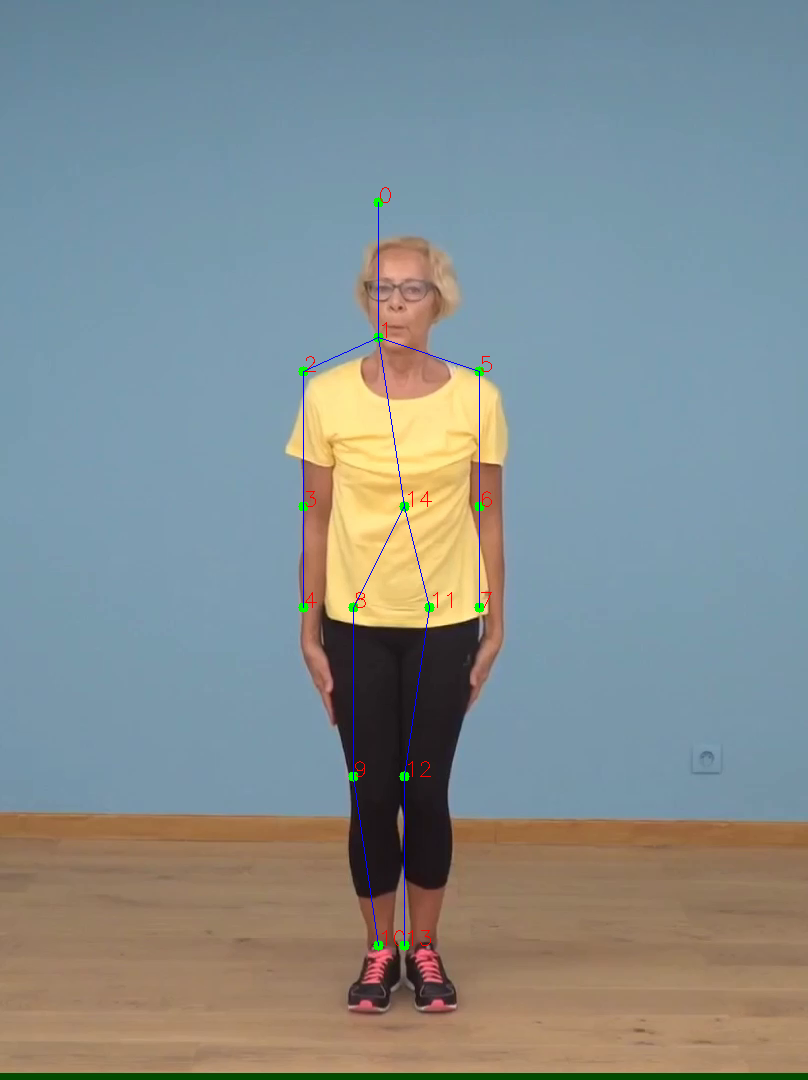

KeyboardInterrupt: 

In [62]:
threshold = 0.1
while cv2.waitKey(1) < 0:
    conectado, frame = captura.read()

    if not conectado:
        break

    imagem_blob = cv2.dnn.blobFromImage(image=frame, scalefactor=1.0 / 255, size=(256, 256))
    network.setInput(imagem_blob)
    output = network.forward()
    posicao_largura = output.shape[2]
    posicao_altura = output.shape[3]

    numero_pontos = 15
    pontos = []
    for i in range(numero_pontos):
        mapa_confianca = output[0, i, :, :]
        _, confianca, _, ponto = cv2.minMaxLoc(mapa_confianca)
        x = int((frame.shape[1] * ponto[0]) / posicao_largura)
        y = int((frame.shape[0] * ponto[1]) / posicao_altura)
        if confianca > threshold:
            cv2.circle(frame, (x, y), 5, (0, 255, 0), thickness=-1)
            cv2.putText(frame, "{}".format(i), (x, y), cv2.FONT_HERSHEY_SIMPLEX, .7, (0, 0, 255))
            pontos.append((x, y))
        else:
            pontos.append(None)

    for conexao in ponto_conexoes:
        parteA = conexao[0]
        parteB = conexao[1]
        if pontos[parteA] and pontos[parteB]:
            cv2.line(frame, pontos[parteA], pontos[parteB], (255, 0, 0))

    if verifica_bracos_acima(pontos) == True and verifica_pernas_afastadas == True:
        cv2.putText(frame, 'Completo!', (50, 200), cv2.FONT_HERSHEY_COMPLEX, 3, (0, 0, 255))

    cv2_imshow(frame)
